#Program 1

In [ ]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

In [1]:
import pandas as pd
import seaborn as sns
from pandas import read_csv
df=read_csv('/content/placement_predict_50k Dataset (1) (1).csv')

In [2]:
#Displays the last five records of the dataset.
df.tail(5)

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
39736,39737,Male,Kolkata,Tier2,CS,AI,Yes,No,6.59,7.27,...,3.0,1.0,72.9,5.0,66.3,72.9,1.0,Mid,1.0,0.0
39737,39738,Female,Jaipur,Tier2,ECE,Embedded,Yes,No,6.44,6.05,...,1.0,0.0,48.9,3.2,46.2,52.3,1.0,Low,1.0,0.0
39738,39739,Male,Chennai,Tier1,CS,AI,No,No,7.42,6.75,...,1.0,1.0,64.7,2.9,54.2,48.8,1.0,Mid,1.0,0.0
39739,39740,Male,Jaipur,Tier3,Civil,Embedded,No,Yes,5.50,6.26,...,1.0,1.0,38.0,2.1,26.8,25.4,0.0,Low,0.0,0.0
39740,39741,Male,Kolkata,Tier1,EE,Embedded,Yes,Yes,6.42,6.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['StudentID']
df.shape

(39741, 31)

In [5]:
df.dtypes

,0
StudentID,int64
Gender,object
City,object
CollegeTier,object
Stream,object
Specialisation,object
Hostel,object
HistoryOfBacklogs,object
SGPA_Sem1,float64
SGPA_Sem2,float64


In [7]:
df['Specialisation']

,Specialisation
0,Networking
1,DataScience
2,DataScience
3,AI
4,DataScience
...,...
39736,AI
39737,Embedded
39738,AI
39739,Embedded


In [8]:
df['Hostel']

,Hostel
0,No
1,Yes
2,Yes
3,No
4,Yes
...,...
39736,Yes
39737,Yes
39738,No
39739,No


In [9]:
df.dtypes.value_counts()

,count
float64,22
object,8
int64,1


In [10]:
print(df.isnull().sum())

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                1
SGPA_Sem7                1
SGPA_Sem8                1
CGPA                     1
AttendancePercent        1
Internships              1
Projects                 1
Workshops             3565
Certifications           1
Publications             1
AptitudeTestScore     3216
SoftSkillsRating      2817
CodingTestScore       2344
MockInterviewScore    3991
ExtraCurricular          1
CGPA_Tier                1
PlacementStatus          1
IsAnomaly                1
dtype: int64


In [13]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})
missing_data

,Missing Values,Percentage
StudentID,0,0.000000
Gender,0,0.000000
City,0,0.000000
CollegeTier,0,0.000000
Stream,0,0.000000
Specialisation,0,0.000000
Hostel,0,0.000000
HistoryOfBacklogs,0,0.000000
SGPA_Sem1,0,0.000000
SGPA_Sem2,0,0.000000


In [19]:
df = df.drop_duplicates()

In [20]:
df.shape

(39741, 31)

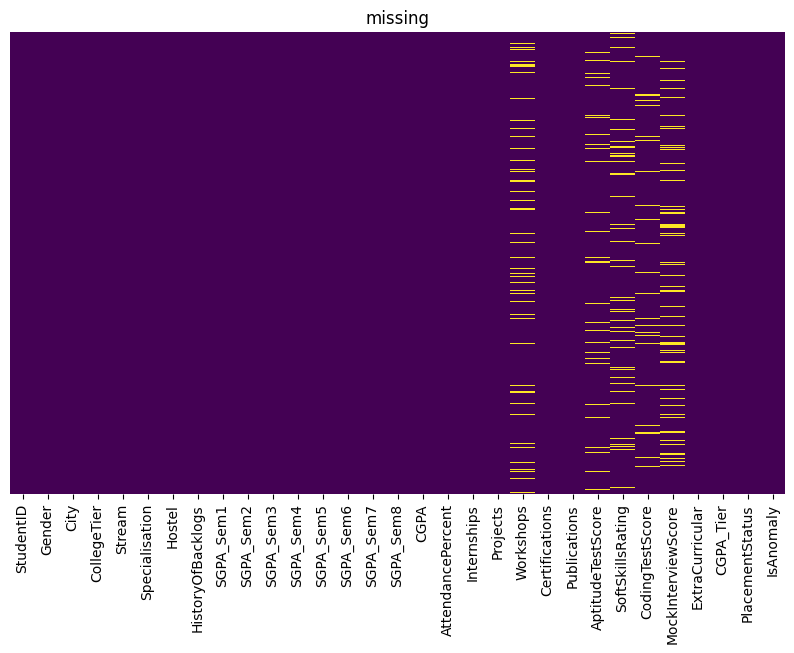

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# cbar=False hides the color bar; yticklabels=False hides row numbers for cleaner v
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("missing")
plt.show()

In [15]:
#Keeps the first occurrence and marks subsequent duplicates as True(if any)
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)
print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [StudentID, Gender, City, CollegeTier, Stream, Specialisation, Hostel, HistoryOfBacklogs, SGPA_Sem1, SGPA_Sem2, SGPA_Sem3, SGPA_Sem4, SGPA_Sem5, SGPA_Sem6, SGPA_Sem7, SGPA_Sem8, CGPA, AttendancePercent, Internships, Projects, Workshops, Certifications, Publications, AptitudeTestScore, SoftSkillsRating, CodingTestScore, MockInterviewScore, ExtraCurricular, CGPA_Tier, PlacementStatus, IsAnomaly]
Index: []

[0 rows x 31 columns]
----------------------------------------


In [16]:
#display rows where null values are present if any
df[df['AptitudeTestScore'].isnull()]

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
7,8,Male,Delhi,Tier2,Mechanical,Embedded,Yes,No,5.87,5.64,...,0.0,0.0,NaN,2.0,35.2,27.8,0.0,Low,0.0,0.0
13,14,Male,Delhi,Tier1,CS,AI,No,No,10.00,10.00,...,3.0,1.0,NaN,NaN,87.9,86.8,1.0,High,1.0,0.0
18,19,Male,Bangalore,Tier2,Mechanical,Embedded,No,No,6.97,6.53,...,1.0,0.0,NaN,1.3,57.9,56.6,0.0,Mid,0.0,0.0
29,30,Female,Pune,Tier2,Civil,Networking,Yes,No,9.94,9.85,...,3.0,2.0,NaN,4.8,60.3,89.3,1.0,High,1.0,0.0
33,34,Male,Kochi,Tier3,Civil,AI,Yes,No,4.52,4.06,...,1.0,1.0,NaN,2.1,27.4,34.6,1.0,Low,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39702,39703,Female,Bangalore,Tier2,EE,Embedded,No,No,5.61,5.34,...,0.0,1.0,NaN,2.7,24.3,30.6,0.0,Low,0.0,0.0
39718,39719,Male,Pune,Tier2,EE,Networking,Yes,Yes,5.69,5.87,...,2.0,0.0,NaN,3.0,53.7,57.0,1.0,Low,0.0,0.0
39722,39723,Male,Mumbai,Tier2,EE,Embedded,Yes,No,9.89,10.00,...,3.0,2.0,NaN,3.0,67.4,72.1,1.0,High,1.0,0.0
39732,39733,Female,Bangalore,Tier3,Mechanical,DataScience,Yes,Yes,5.06,4.71,...,0.0,0.0,NaN,2.5,28.0,24.8,1.0,Low,0.0,0.0


In [17]:
#  Checking for Duplicates

df.duplicated().sum()
df = df.drop_duplicates()

In [21]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
count,39741.000000,39741.000000,39741.000000,39741.000000,39741.000000,39741.000000,39740.000000,39740.000000,39740.000000,39740.000000,...,36176.000000,39740.000000,39740.000000,36525.000000,36924.000000,37397.000000,35750.000000,39740.000000,39740.000000,39740.000000
mean,19871.000000,7.212368,7.224895,7.236840,7.247963,7.260014,7.276061,7.283626,7.293801,7.246789,...,1.802825,1.928988,0.732687,68.777095,3.151888,57.365297,55.360685,0.531656,0.657071,0.035304
std,11472.382861,1.514694,1.528094,1.548215,1.567559,1.583693,1.600387,1.618029,1.635032,1.613896,...,1.036614,1.174196,0.717490,15.379503,0.980668,20.984386,17.499661,0.499003,0.474694,0.184551
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,15.900000,0.000000,0.000000,0.000000
25%,9936.000000,6.100000,6.090000,6.090000,6.080000,6.080000,6.080000,6.070000,6.060000,6.040000,...,1.000000,1.000000,0.000000,58.300000,2.400000,45.900000,44.200000,0.000000,0.000000,0.000000
50%,19871.000000,7.190000,7.210000,7.230000,7.240000,7.260000,7.280000,7.300000,7.310000,7.260000,...,2.000000,2.000000,1.000000,69.800000,3.100000,57.600000,54.700000,1.000000,1.000000,0.000000
75%,29806.000000,8.340000,8.360000,8.390000,8.420000,8.460000,8.500000,8.520000,8.560000,8.480000,...,3.000000,3.000000,1.000000,79.600000,3.900000,73.200000,69.100000,1.000000,1.000000,0.000000
max,39741.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,4.000000,5.000000,3.000000,100.000000,5.000000,100.000000,100.000000,1.000000,1.000000,1.000000


#Program 2

In [22]:
import pandas as pd
import numpy as np

In [23]:
import seaborn as sns

In [24]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [34]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [35]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [36]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  \
StudentID            1.000000  -0.004427  -0.003160  -0.003876  -0.002744   
SGPA_Sem1           -0.004427   1.000000   0.963827   0.963737   0.963568   
SGPA_Sem2           -0.003160   0.963827   1.000000   0.964849   0.964776   
SGPA_Sem3           -0.003876   0.963737   0.964849   1.000000   0.965488   
SGPA_Sem4           -0.002744   0.963568   0.964776   0.965488   1.000000   
SGPA_Sem5           -0.002882   0.962859   0.964657   0.965440   0.966443   
SGPA_Sem6           -0.002125   0.962381   0.964147   0.965765   0.966314   
SGPA_Sem7           -0.002992   0.961770   0.963793   0.965298   0.966054   
SGPA_Sem8           -0.004896   0.960499   0.962990   0.964681   0.966015   
CGPA                -0.003592   0.910004   0.911392   0.911843   0.912271   
AttendancePercent    0.001729   0.496491   0.506226   0.514162   0.521752   
Internships         -0.002286   0.444906   0.455

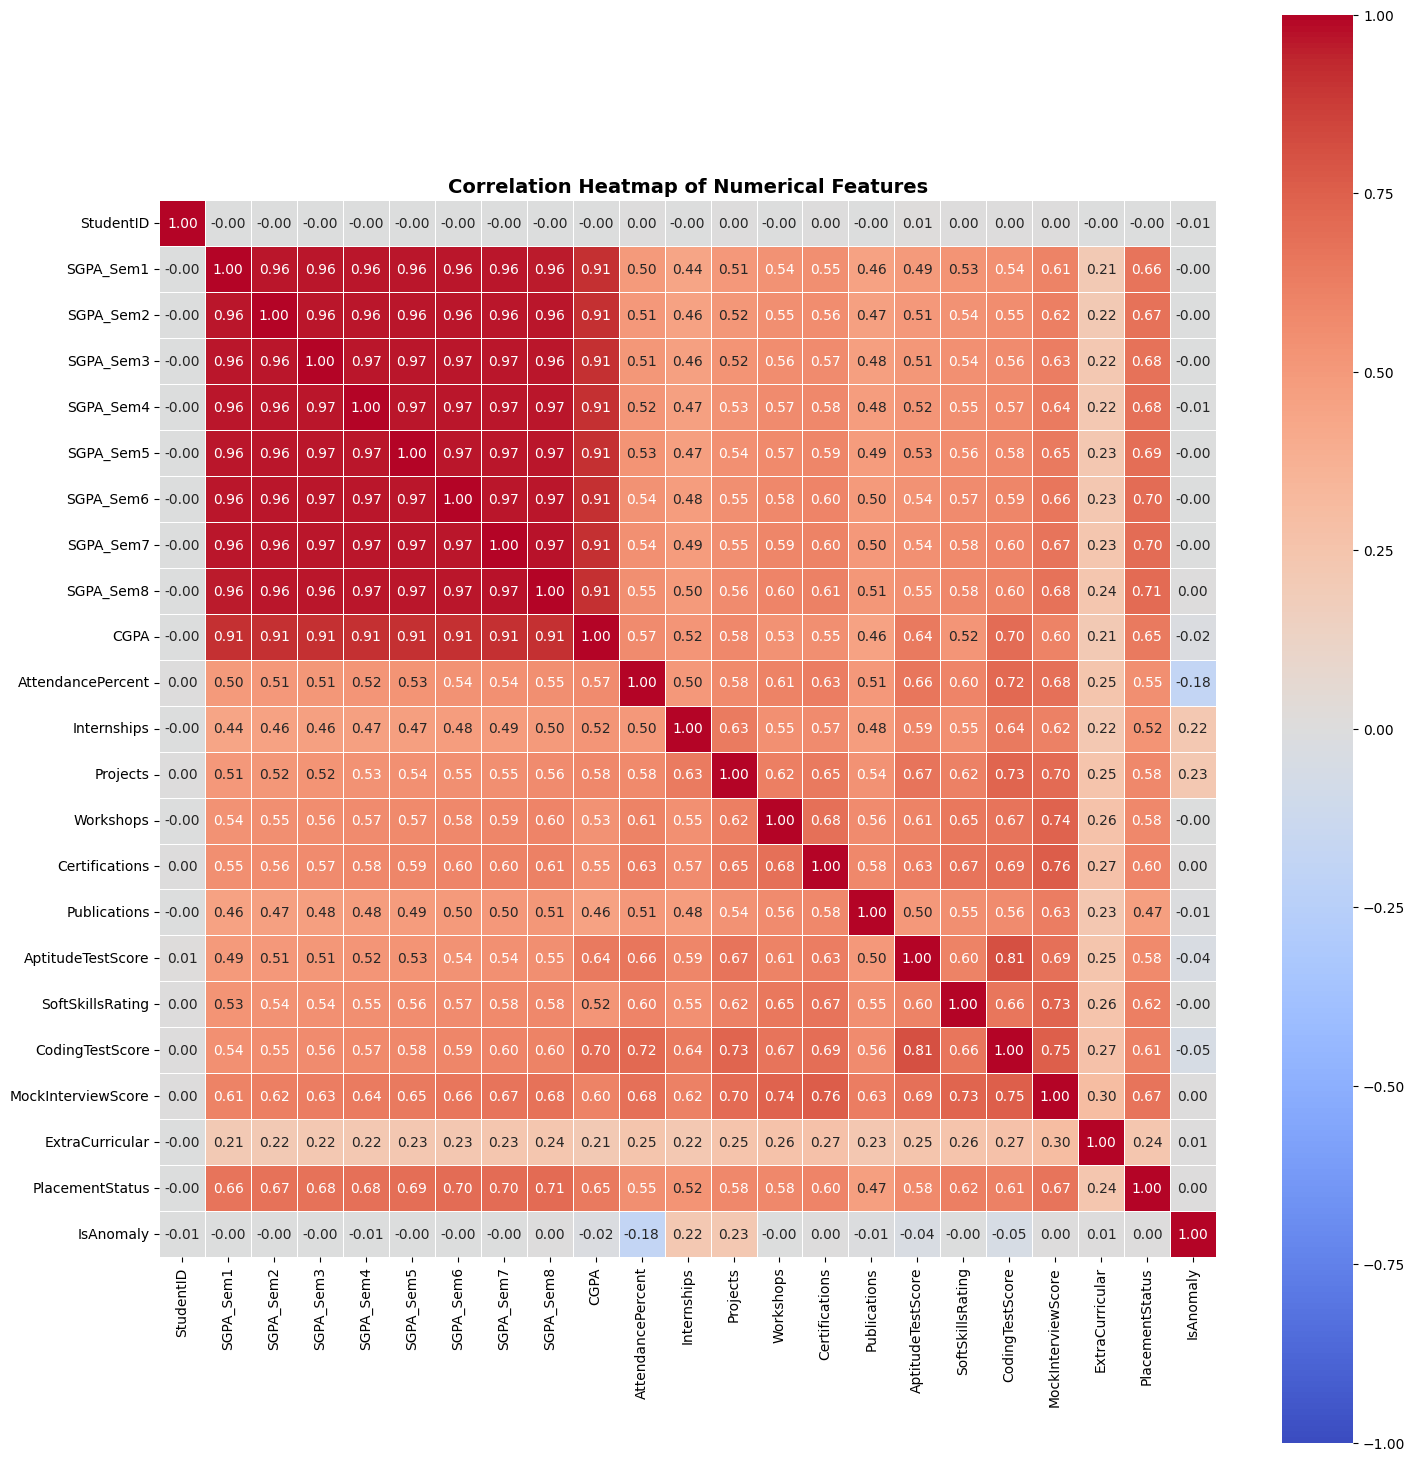

In [33]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [32]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [31]:
import os
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs PlacementStatus
# -------------------------------------------------------------
target_col = "PlacementStatus"
output_dir = "/content/" # Define output_dir here
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()


        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    print("\nAll EDA tasks completed successfully!")
else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

Exported boxplot to: /content/boxplot_StudentID_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem1_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem2_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem3_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem4_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem5_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem6_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem7_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_SGPA_Sem8_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_CGPA_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_AttendancePercent_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_Internships_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_Projects_vs_PlacementStatus.png
Exported boxplot to: /content/boxplot_Workshops_vs_PlacementStatus.png
Ex

<Figure size 1500x800 with 0 Axes>

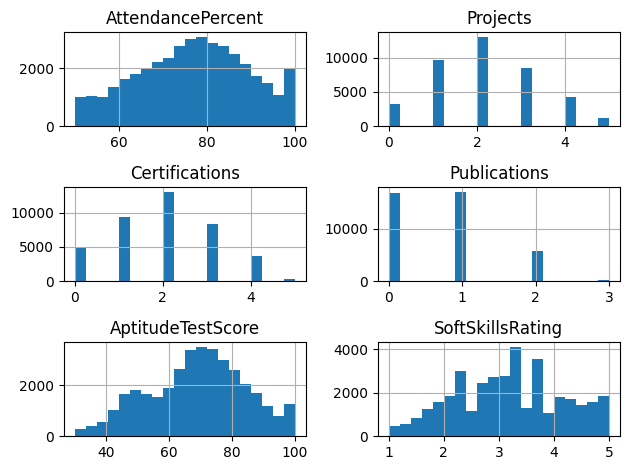

In [26]:
features = ["AttendancePercent", "Projects", "Certifications", "Publications","AptitudeTestScore", "SoftSkillsRating" ]

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()